In [1]:
import numpy as np
import pandas as pd
import glob
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
import glob

ts_files = glob.glob("ts_data/ts_seed_*.parquet")
q1_files = glob.glob("q_tables/Q1_seed_*.npy")
q2_files = glob.glob("q_tables/Q2_seed_*.npy")

print(f"Liczba plików ts: {len(ts_files)}")
print(f"Liczba plików Q1: {len(q1_files)}")
print(f"Liczba plików Q2: {len(q2_files)}")

# Sprawdźmy wspólne seed'y
seeds_ts = {int(f.split('_')[-1].split('.')[0]) for f in ts_files}
seeds_q1 = {int(f.split('_')[-1].split('.')[0]) for f in q1_files}
seeds_q2 = {int(f.split('_')[-1].split('.')[0]) for f in q2_files}
common = seeds_ts & seeds_q1 & seeds_q2
print(f"Liczba seedów z wszystkimi plikami: {len(common)}")

Liczba plików ts: 1000
Liczba plików Q1: 1000
Liczba plików Q2: 1000
Liczba seedów z wszystkimi plikami: 1000


Znaleziono 1000 plików.


Przetwarzanie seedów: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:16<00:00, 59.05it/s]


Zapisano 1000 wyników do analysis_results.csv


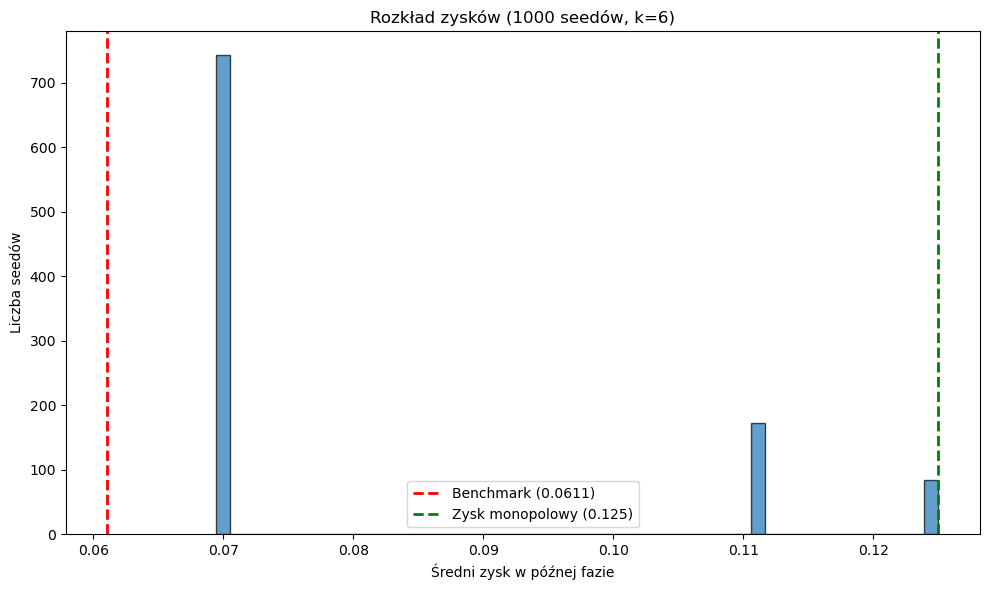

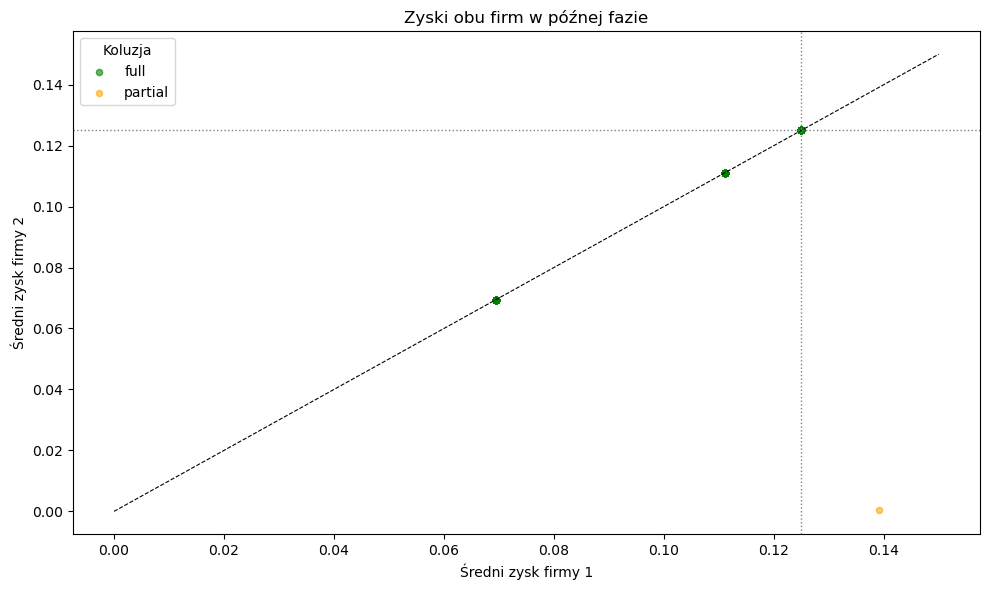


=== PODSUMOWANIE ===
Odsetek seedów w równowadze Nasha: 99.90%
collusion
full       999
partial      1
Name: count, dtype: int64


In [6]:
import numpy as np
import pandas as pd
import glob
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

# ========== PARAMETRY ==========
k = 6
T = 500000
tail_frac = 0.1                # bierzemy ostatnie 10% okresów
tail_len = int(T * tail_frac)   # 50 000
benchmark = 0.0611              # dla k=6 (z artykułu)
tol = 1e-4                      # tolerancja dla uznania Γ ≈ 1

# Ścieżki do danych
ts_dir = "ts_data"              # katalog z plikami .parquet
q_dir = "q_tables"              # katalog z macierzami Q .npy

# ========== PRZETWARZANIE ==========
files = glob.glob(f"{ts_dir}/ts_seed_*.parquet")
print(f"Znaleziono {len(files)} plików.")

results = []

for f in tqdm(files, desc="Przetwarzanie seedów"):
    seed = int(os.path.basename(f).split('_')[-1].split('.')[0])

    # Wczytaj macierze Q
    try:
        Q1 = np.load(f"{q_dir}/Q1_seed_{seed}.npy")
        Q2 = np.load(f"{q_dir}/Q2_seed_{seed}.npy")
    except FileNotFoundError:
        print(f"Brak Q dla seed {seed}, pomijam.")
        continue

    # Wczytaj szereg czasowy (tylko ostatnie 10%)
    df = pd.read_parquet(f)
    df_tail = df.iloc[-tail_len:] if len(df) > tail_len else df

    # Wyciągnij kolumny jako tablice numpy (szybciej)
    p1 = df_tail['p1'].values
    p2 = df_tail['p2'].values
    pi1 = df_tail['pi1'].values
    pi2 = df_tail['pi2'].values

    # Konwersja cen na indeksy 0..k
    i1 = np.round(p1 * k).astype(int)
    i2 = np.round(p2 * k).astype(int)
    i1 = np.clip(i1, 0, k)
    i2 = np.clip(i2, 0, k)

    # Maksima Q dla firmy 1 (zawsze 2D)
    Q1_max = Q1.max(axis=1)   # max po akcjach dla każdej ceny konkurenta

    # Oblicz Γ w zależności od tego, czy firma 2 ma pamięć
    if Q2.ndim == 1:
        # FIRMA 2 BEZ PAMIĘCI – Q to wektor
        Q2_max_val = Q2.max()                 # globalne maksimum
        gamma1 = Q1[i2, i1] / Q1_max[i2]
        gamma2 = Q2[i2] / Q2_max_val
        gamma = (gamma1 + gamma2) / 2
    else:
        # FIRMA 2 Z PAMIĘCIĄ – Q to macierz
        Q2_max = Q2.max(axis=1)
        gamma1 = Q1[i2, i1] / Q1_max[i2]
        gamma2 = Q2[i1, i2] / Q2_max[i1]
        gamma = (gamma1 + gamma2) / 2

    avg_gamma = np.nanmean(gamma)

    # Średnie zyski
    avg_pi1 = pi1.mean()
    avg_pi2 = pi2.mean()
    avg_profit = (avg_pi1 + avg_pi2) / 2

    # Czy to równowaga Nasha?
    nash = avg_gamma > (1 - tol)

    # Klasyfikacja koluzji
    if nash and avg_profit > benchmark:
        coll = 'full'
    elif avg_profit > benchmark:
        coll = 'partial'
    else:
        coll = 'none'

    results.append({
        'seed': seed,
        'avg_gamma': avg_gamma,
        'is_nash': nash,
        'avg_profit': avg_profit,
        'avg_pi1': avg_pi1,
        'avg_pi2': avg_pi2,
        'collusion': coll
    })

# ========== ZAPIS WYNIKÓW ==========
df_res = pd.DataFrame(results)
df_res.to_csv('analysis_results.csv', index=False)
print(f"Zapisano {len(df_res)} wyników do analysis_results.csv")

# ========== WYKRESY ==========

# 1. Histogram średnich zysków
plt.figure(figsize=(10,6))
plt.hist(df_res['avg_profit'], bins=50, alpha=0.7, edgecolor='black')
plt.axvline(benchmark, color='red', linestyle='--', linewidth=2, label=f'Benchmark ({benchmark})')
plt.axvline(0.125, color='green', linestyle='--', linewidth=2, label='Zysk monopolowy (0.125)')
plt.xlabel('Średni zysk w późnej fazie')
plt.ylabel('Liczba seedów')
plt.title('Rozkład zysków (1000 seedów, k=6)')
plt.legend()
plt.tight_layout()
plt.savefig('histogram_profit.png', dpi=150)
plt.show()

# 2. Wykres punktowy zysków obu firm
plt.figure(figsize=(10,6))
colors = {'full': 'green', 'partial': 'orange', 'none': 'red'}
for coll, grp in df_res.groupby('collusion'):
    plt.scatter(grp['avg_pi1'], grp['avg_pi2'],
                c=colors[coll], label=coll, alpha=0.6, s=20)
plt.plot([0, 0.15], [0, 0.15], 'k--', linewidth=0.8)   # linia 45°
plt.axhline(0.125, color='gray', linestyle=':', linewidth=1)
plt.axvline(0.125, color='gray', linestyle=':', linewidth=1)
plt.xlabel('Średni zysk firmy 1')
plt.ylabel('Średni zysk firmy 2')
plt.title('Zyski obu firm w późnej fazie')
plt.legend(title='Koluzja')
plt.tight_layout()
plt.savefig('scatter_profit.png', dpi=150)
plt.show()

# 3. Podstawowe statystyki
print("\n=== PODSUMOWANIE ===")
print(f"Odsetek seedów w równowadze Nasha: {df_res['is_nash'].mean():.2%}")
print(df_res['collusion'].value_counts())

Znaleziono 1000 plików.


Przetwarzanie seedów: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:18<00:00, 53.45it/s]


Zapisano 1000 wyników do analysis_results.csv


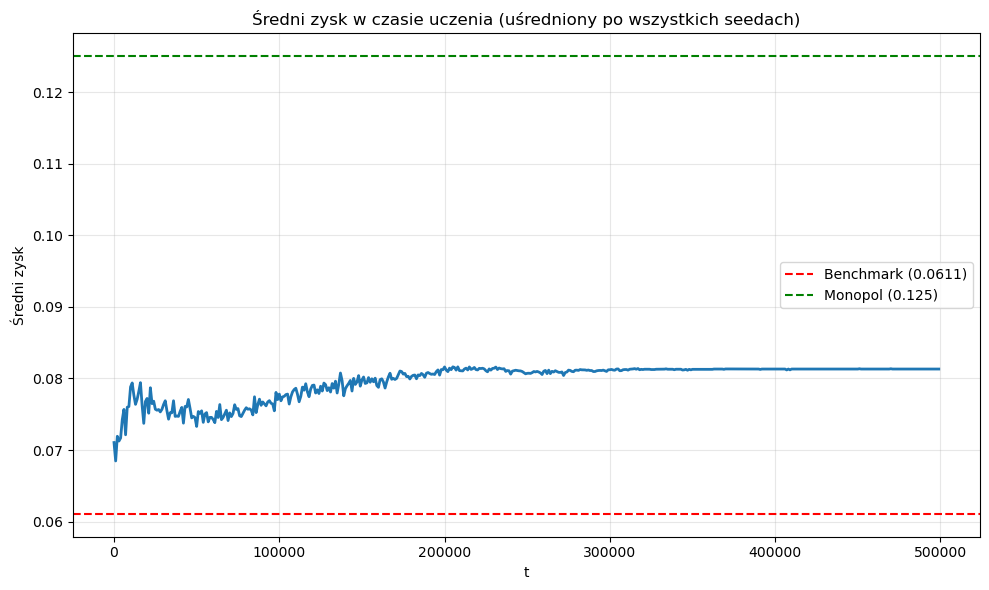

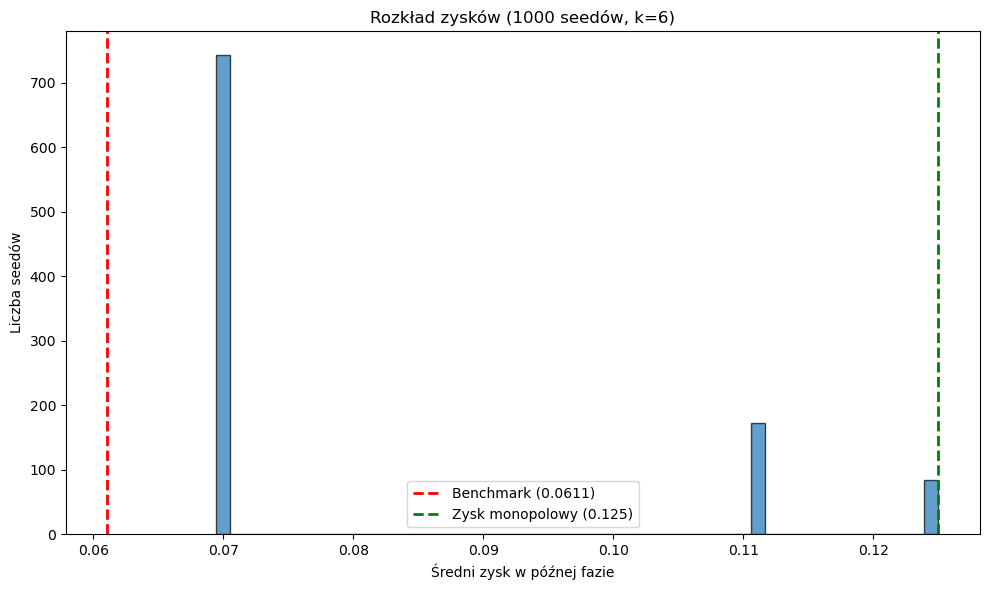

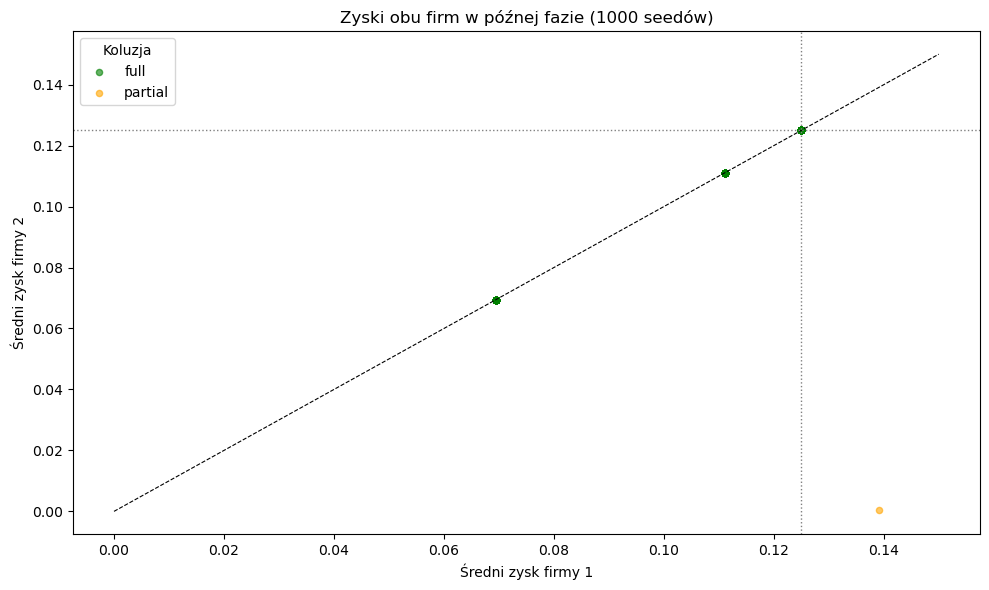


=== PODSUMOWANIE KOŃCOWE (T=500k) ===
Średnia optymalność Γ: 1.0000
Odsetek seedów w równowadze Nasha: 99.90%
collusion
full       999
partial      1
Name: count, dtype: int64


In [7]:
import numpy as np
import pandas as pd
import glob
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

# ========== PARAMETRY ==========
k = 6
T = 500000
tail_frac = 0.1                # ostatnie 10% okresów
tail_len = int(T * tail_frac)   # 50 000
benchmark = 0.0611              # dla k=6 (z artykułu)
tol = 1e-4                      # tolerancja dla Γ ≈ 1

# Ścieżki do danych
ts_dir = "ts_data"              # katalog z plikami .parquet
q_dir = "q_tables"              # katalog z macierzami Q .npy

# ========== PRZETWARZANIE ==========
files = glob.glob(f"{ts_dir}/ts_seed_*.parquet")
print(f"Znaleziono {len(files)} plików.")

# Inicjalizacja tablic do agregacji czasowej (dla wszystkich seedów)
n_seeds = len(files)
profit_over_time = np.zeros((n_seeds, T))   # każdy wiersz: zysk w kolejnych okresach dla jednego seeda

results = []

for idx, f in enumerate(tqdm(files, desc="Przetwarzanie seedów")):
    seed = int(os.path.basename(f).split('_')[-1].split('.')[0])

    # Wczytaj macierze Q
    try:
        Q1 = np.load(f"{q_dir}/Q1_seed_{seed}.npy")
        Q2 = np.load(f"{q_dir}/Q2_seed_{seed}.npy")
    except FileNotFoundError:
        print(f"Brak Q dla seed {seed}, pomijam.")
        continue

    # Wczytaj cały szereg czasowy
    df = pd.read_parquet(f)
    # Upewnij się, że długość = T (w razie gdyby plik był przycięty)
    if len(df) != T:
        print(f"Ostrzeżenie: seed {seed} ma długość {len(df)} zamiast {T}")
        continue

    # Zysk w każdym okresie = (pi1 + pi2)/2
    profit_series = (df['pi1'].values + df['pi2'].values) / 2.0
    profit_over_time[idx, :] = profit_series

    # Ogon (ostatnie 10%) do dalszych analiz
    df_tail = df.iloc[-tail_len:]

    p1 = df_tail['p1'].values
    p2 = df_tail['p2'].values
    pi1 = df_tail['pi1'].values
    pi2 = df_tail['pi2'].values

    # Indeksy cen
    i1 = np.round(p1 * k).astype(int)
    i2 = np.round(p2 * k).astype(int)
    i1 = np.clip(i1, 0, k)
    i2 = np.clip(i2, 0, k)

    # Maksima Q1
    Q1_max = Q1.max(axis=1)

    # Oblicz Γ w zależności od wymiaru Q2
    if Q2.ndim == 1:
        # Firma 2 bez pamięci
        Q2_max_val = Q2.max()
        gamma1 = Q1[i2, i1] / Q1_max[i2]
        gamma2 = Q2[i2] / Q2_max_val
        gamma = (gamma1 + gamma2) / 2
    else:
        # Firma 2 z pamięcią
        Q2_max = Q2.max(axis=1)
        gamma1 = Q1[i2, i1] / Q1_max[i2]
        gamma2 = Q2[i1, i2] / Q2_max[i1]
        gamma = (gamma1 + gamma2) / 2

    avg_gamma = np.nanmean(gamma)

    avg_pi1 = pi1.mean()
    avg_pi2 = pi2.mean()
    avg_profit = (avg_pi1 + avg_pi2) / 2

    nash = avg_gamma > (1 - tol)

    if nash and avg_profit > benchmark:
        coll = 'full'
    elif avg_profit > benchmark:
        coll = 'partial'
    else:
        coll = 'none'

    results.append({
        'seed': seed,
        'avg_gamma': avg_gamma,
        'is_nash': nash,
        'avg_profit': avg_profit,
        'avg_pi1': avg_pi1,
        'avg_pi2': avg_pi2,
        'collusion': coll
    })

# ========== AGGREGACJA CZASOWA ==========
# Uśrednij zysk po wszystkich seedach w każdym okresie
profit_avg_over_time = profit_over_time.mean(axis=0)

# Opcjonalnie: próbkowanie co N okresów, aby wykres był czytelny
step = 1000   # co 1000 okresów
t_sampled = np.arange(0, T, step)
profit_sampled = profit_avg_over_time[::step]

# ========== ZAPIS WYNIKÓW ==========
df_res = pd.DataFrame(results)
df_res.to_csv('analysis_results.csv', index=False)
print(f"Zapisano {len(df_res)} wyników do analysis_results.csv")

# ========== WYKRESY ==========

# 1. Średni zysk w czasie (odpowiednik panelu "Average Profitability" z Figure 1)
plt.figure(figsize=(10,6))
plt.plot(t_sampled, profit_sampled, linewidth=2)
plt.xlabel('t')
plt.ylabel('Średni zysk')
plt.title('Średni zysk w czasie uczenia (uśredniony po wszystkich seedach)')
plt.axhline(benchmark, color='red', linestyle='--', label=f'Benchmark ({benchmark})')
plt.axhline(0.125, color='green', linestyle='--', label='Monopol (0.125)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('avg_profit_over_time.png', dpi=150)
plt.show()

# 2. Histogram zysków (lewy panel Figure 2)
plt.figure(figsize=(10,6))
plt.hist(df_res['avg_profit'], bins=50, alpha=0.7, edgecolor='black')
plt.axvline(benchmark, color='red', linestyle='--', linewidth=2, label=f'Benchmark ({benchmark})')
plt.axvline(0.125, color='green', linestyle='--', linewidth=2, label='Zysk monopolowy (0.125)')
plt.xlabel('Średni zysk w późnej fazie')
plt.ylabel('Liczba seedów')
plt.title(f'Rozkład zysków ({len(df_res)} seedów, k=6)')
plt.legend()
plt.tight_layout()
plt.savefig('histogram_profit.png', dpi=150)
plt.show()

# 3. Scatter plot zysków firm (prawy panel Figure 2)
plt.figure(figsize=(10,6))
colors = {'full': 'green', 'partial': 'orange', 'none': 'red'}
for coll, grp in df_res.groupby('collusion'):
    plt.scatter(grp['avg_pi1'], grp['avg_pi2'],
                c=colors[coll], label=coll, alpha=0.6, s=20)
plt.plot([0, 0.15], [0, 0.15], 'k--', linewidth=0.8)   # linia 45°
plt.axhline(0.125, color='gray', linestyle=':', linewidth=1)
plt.axvline(0.125, color='gray', linestyle=':', linewidth=1)
plt.xlabel('Średni zysk firmy 1')
plt.ylabel('Średni zysk firmy 2')
plt.title(f'Zyski obu firm w późnej fazie ({len(df_res)} seedów)')
plt.legend(title='Koluzja')
plt.tight_layout()
plt.savefig('scatter_profit.png', dpi=150)
plt.show()

# 4. Podsumowanie statystyk
print("\n=== PODSUMOWANIE KOŃCOWE (T=500k) ===")
print(f"Średnia optymalność Γ: {df_res['avg_gamma'].mean():.4f}")
print(f"Odsetek seedów w równowadze Nasha: {df_res['is_nash'].mean():.2%}")
print(df_res['collusion'].value_counts())

Liczba plików: 1000


Wczytywanie trajektorii: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 74.06it/s]


Poprawnych trajektorii: 1000
Zapisano etykiety grup do cluster_labels.csv
Liczebności grup:
Grupa 0: n=122 (12.2%)
Grupa 1: n=60 (6.0%)
Grupa 2: n=621 (62.1%)
Grupa 3: n=197 (19.7%)


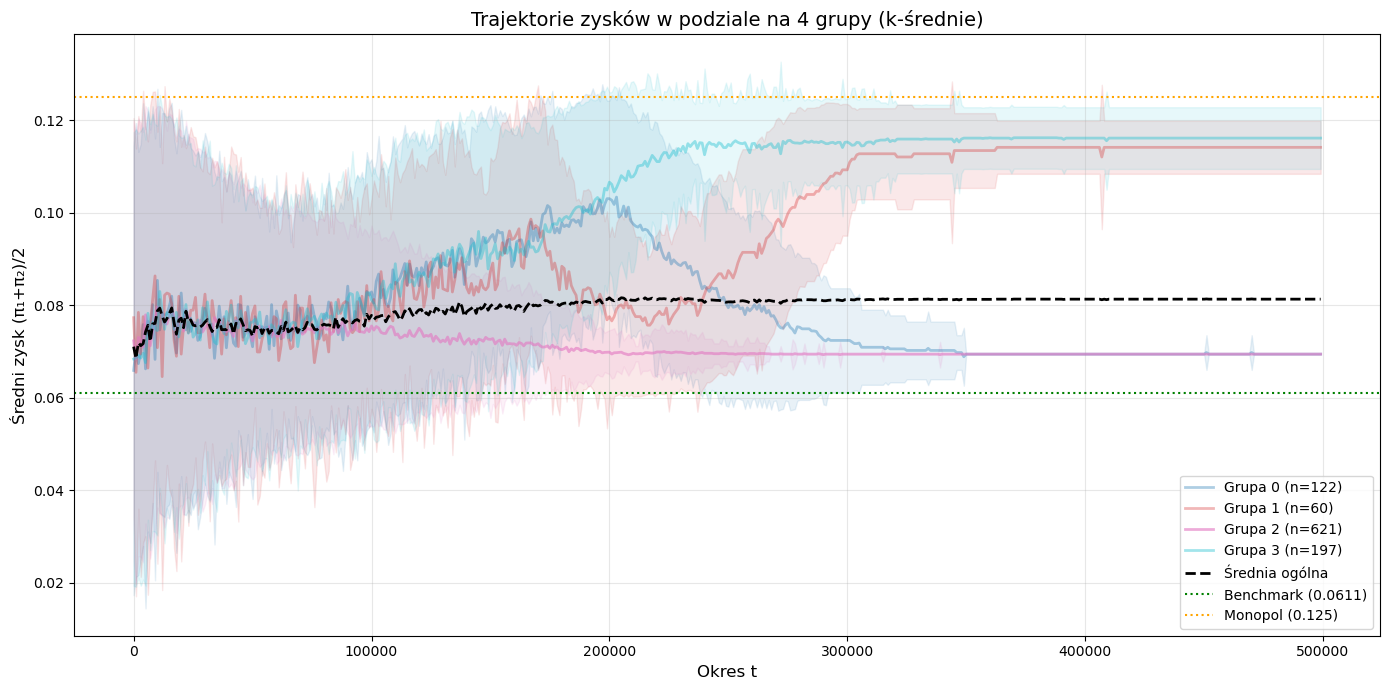

In [8]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# ===== PARAMETRY =====
step = 1000
T = 500000
t_points = np.arange(0, T, step)          # punkty czasowe
benchmark = 0.0611
monopoly = 0.125
ts_dir = "ts_data"
n_clusters = 4                             # liczba grup
normalize = False                          # czy normalizować trajektorie przed klasteryzacją?

# ===== WCZYTANIE DANYCH =====
files = glob.glob(f"{ts_dir}/ts_seed_*.parquet")
print(f"Liczba plików: {len(files)}")

n_seeds = len(files)
n_times = len(t_points)
trajectories = np.full((n_seeds, n_times), np.nan)   # macierz wypełniona NaN

for i, f in enumerate(tqdm(files, desc="Wczytywanie trajektorii")):
    df = pd.read_parquet(f)
    # Upewniamy się, że DataFrame ma odpowiednią długość
    if len(df) < T:
        print(f"Ostrzeżenie: plik {f} ma długość {len(df)} < {T} – pomijam.")
        continue
    # Próbkowanie co step
    df_sampled = df.iloc[::step].copy()
    # Jeśli po próbkowaniu jest więcej punktów niż n_times, obetnij
    if len(df_sampled) > n_times:
        df_sampled = df_sampled.iloc[:n_times]
    # Jeśli mniej – uzupełnij NaN (ale nie powinno się zdarzyć)
    if len(df_sampled) < n_times:
        print(f"Ostrzeżenie: plik {f} ma za mało punktów po próbkowaniu – uzupełniam NaN.")
        temp = np.full(n_times, np.nan)
        temp[:len(df_sampled)] = (df_sampled['pi1'] + df_sampled['pi2']).values / 2
        trajectories[i, :] = temp
    else:
        trajectories[i, :] = (df_sampled['pi1'] + df_sampled['pi2']).values / 2

# Usuń wiersze zawierające NaN (seedy z niekompletnymi danymi)
valid_mask = ~np.isnan(trajectories).any(axis=1)
trajectories = trajectories[valid_mask]
print(f"Poprawnych trajektorii: {len(trajectories)}")

if len(trajectories) == 0:
    raise ValueError("Brak poprawnych danych do klasteryzacji.")

# ===== OPCJONALNA NORMALIZACJA =====
if normalize:
    # Standaryzacja: (x - średnia) / odchylenie std – dla każdej trajektorii osobno
    scaler = StandardScaler()
    traj_norm = scaler.fit_transform(trajectories.T).T   # transpozycja, bo scaler działa na kolumny
else:
    traj_norm = trajectories

# ===== KLASTERYZACJA =====
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(traj_norm)

# ===== ZAPIS LABELI =====
# Odczytaj numery seedów z nazw plików (tylko dla zachowanych wierszy)
seeds_valid = []
for f in np.array(files)[valid_mask]:
    seed = int(os.path.basename(f).split('_')[-1].split('.')[0])
    seeds_valid.append(seed)
df_labels = pd.DataFrame({'seed': seeds_valid, 'cluster': labels})
df_labels.to_csv('cluster_labels.csv', index=False)
print("Zapisano etykiety grup do cluster_labels.csv")

# ===== STATYSTYKI GRUP =====
unique, counts = np.unique(labels, return_counts=True)
print("Liczebności grup:")
for u, c in zip(unique, counts):
    print(f"Grupa {u}: n={c} ({c/len(labels):.1%})")

# ===== WYKRES =====
plt.figure(figsize=(14, 7))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for label, color in zip(unique, colors):
    mask = labels == label
    group_trajs = trajectories[mask]       # używamy oryginalnych (nieznormalizowanych) trajektorii do wykresu
    mean_traj = group_trajs.mean(axis=0)
    std_traj = group_trajs.std(axis=0)
    # Przezroczystość proporcjonalna do liczebności
    alpha = 0.3 + 0.5 * (len(group_trajs) / len(trajectories))
    # Linia średniej
    plt.plot(t_points, mean_traj, color=color, linewidth=2, alpha=alpha,
             label=f'Grupa {label} (n={len(group_trajs)})')
    # Obszar odchylenia standardowego (cieniowanie)
    plt.fill_between(t_points, mean_traj - std_traj, mean_traj + std_traj,
                     color=color, alpha=0.1)

# Średnia ogólna
plt.plot(t_points, trajectories.mean(axis=0), 'k--', linewidth=2, label='Średnia ogólna')

# Linie odniesienia
plt.axhline(benchmark, color='green', linestyle=':', linewidth=1.5, label=f'Benchmark ({benchmark})')
plt.axhline(monopoly, color='orange', linestyle=':', linewidth=1.5, label=f'Monopol ({monopoly})')

plt.xlabel('Okres t', fontsize=12)
plt.ylabel('Średni zysk (π₁+π₂)/2', fontsize=12)
plt.title(f'Trajektorie zysków w podziale na {n_clusters} grupy (k-średnie)', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clusters_profit.png', dpi=150)
plt.show()

/tmp/ipykernel_632051/3718262703.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


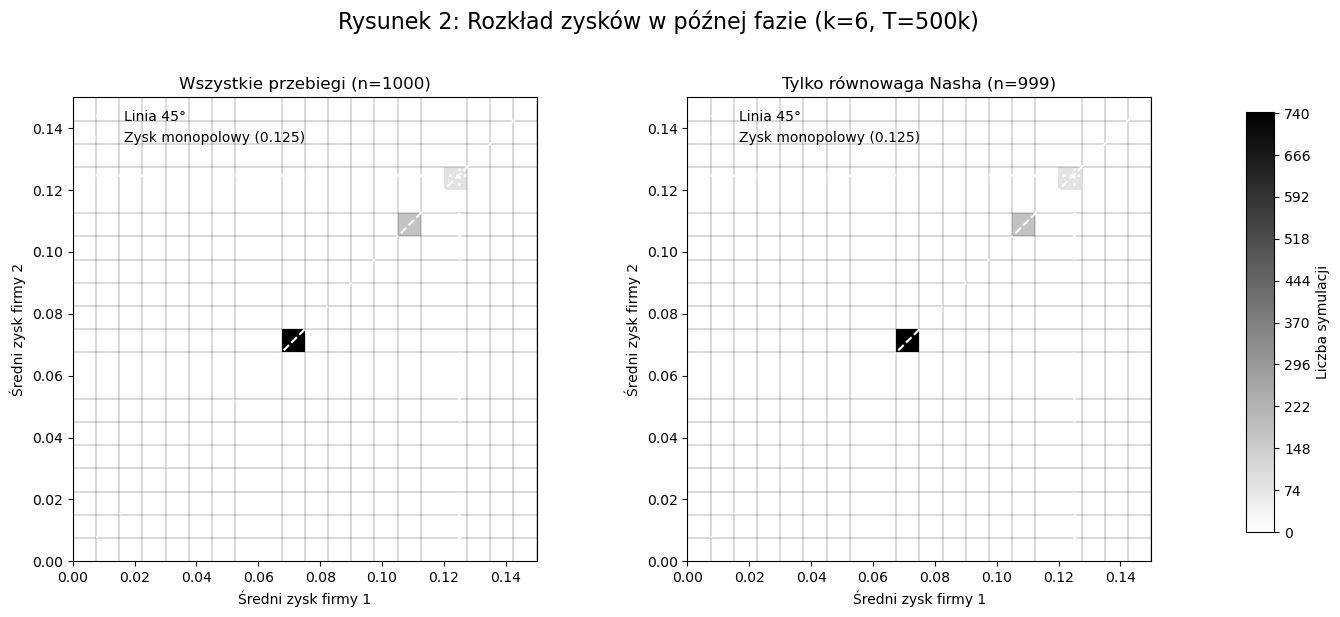

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Załóżmy, że df_res jest już wczytany (np. z pliku analysis_results.csv)
# df_res = pd.read_csv('analysis_results.csv')

bins = 20
range_vals = [0, 0.15]
monopoly = 0.125

# Podział na dane z równowagą Nasha
df_nash = df_res[df_res['is_nash'] == True]

def plot_panel(ax, data, title, colormap='gray_r', linecolor='white'):
    """
    Rysuje histogram 2D zysków firm.
    
    Parametry:
    - ax: obiekt osi
    - data: DataFrame z kolumnami avg_pi1, avg_pi2
    - title: tytuł
    - colormap: mapa kolorów (domyślnie 'gray_r' - odwrócona szarość)
    - linecolor: kolor linii odniesienia i siatki
    """
    # Histogram 2D
    H, xedges, yedges = np.histogram2d(data['avg_pi1'], data['avg_pi2'],
                                       bins=bins, range=[range_vals, range_vals])
    H = H.T  # transpozycja, aby oś x była pierwszym wymiarem
    
    im = ax.imshow(H, origin='lower', extent=[0, 0.15, 0, 0.15],
                   cmap=colormap, aspect='equal', interpolation='nearest',
                   vmin=0, vmax=H.max())
    
    # Siatka (linie między komórkami)
    ax.set_xticks(np.linspace(0, 0.15, bins+1), minor=True)
    ax.set_yticks(np.linspace(0, 0.15, bins+1), minor=True)
    # ax.grid(True, which='minor', color=linecolor, linewidth=0.5, linestyle='-')
    # ax.tick_params(which='minor', bottom=False, left=False)
    ax.grid(True,
            which='minor',
            color='black',       # ciemna siatka
            linewidth=0.3,       # trochę grubsza
            linestyle='-',
            alpha=0.7,           # bez przezroczystości
            zorder=3)            # nad heatmapą
    ax.tick_params(which='minor', bottom=False, left=False)

    
    # Linie odniesienia
    ax.plot([0, 0.15], [0, 0.15], color=linecolor, linestyle='--', linewidth=1.5, label='Linia 45°')
    ax.axhline(monopoly, color=linecolor, linestyle=':', linewidth=2, label='Zysk monopolowy (0.125)')
    ax.axvline(monopoly, color=linecolor, linestyle=':', linewidth=2)
    
    ax.set_xlim(0, 0.15)
    ax.set_ylim(0, 0.15)
    ax.set_xlabel('Średni zysk firmy 1')
    ax.set_ylabel('Średni zysk firmy 2')
    ax.set_title(f'{title} (n={len(data)})')
    ax.legend(loc='upper left', frameon=False)
    return im, H

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Lewy panel – wszystkie przebiegi
im1, H_all = plot_panel(axes[0], df_res, 'Wszystkie przebiegi', colormap='gray_r', linecolor='white')

# Prawy panel – tylko Nash
im2, H_nash = plot_panel(axes[1], df_nash, 'Tylko równowaga Nasha', colormap='gray_r', linecolor='white')

# Wspólny pasek kolorów – automatyczne ticks
max_val = max(H_all.max(), H_nash.max())
step = max(1, max_val // 10)  # co najwyżej 10 przedziałów
ticks = np.arange(0, max_val + step, step)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im1, cax=cbar_ax, ticks=ticks)
cbar.set_label('Liczba symulacji')

plt.suptitle('Rysunek 2: Rozkład zysków w późnej fazie (k=6, T=500k)', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('figure2_klein_gray_reverse.png', dpi=300, bbox_inches='tight')
plt.show()

Liczba plików: 1000


Wczytywanie trajektorii: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 73.75it/s]


Liczebności grup:
Grupa 0: n=122
Grupa 1: n=60
Grupa 2: n=621
Grupa 3: n=197
Wykresy zapisane jako cluster_0.png, cluster_1.png, ...


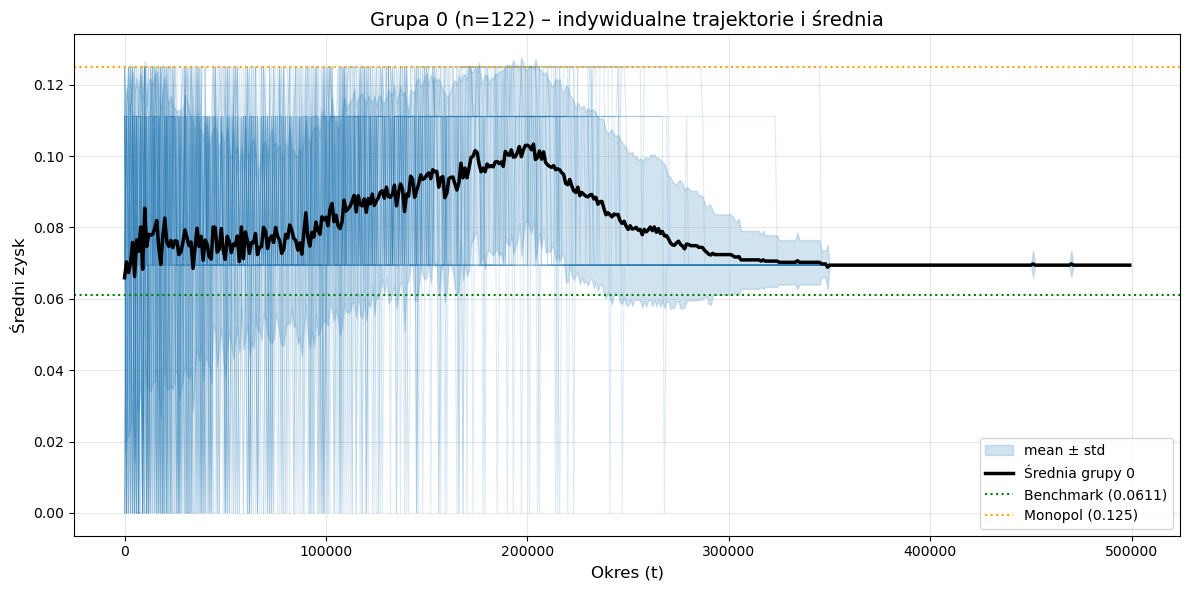

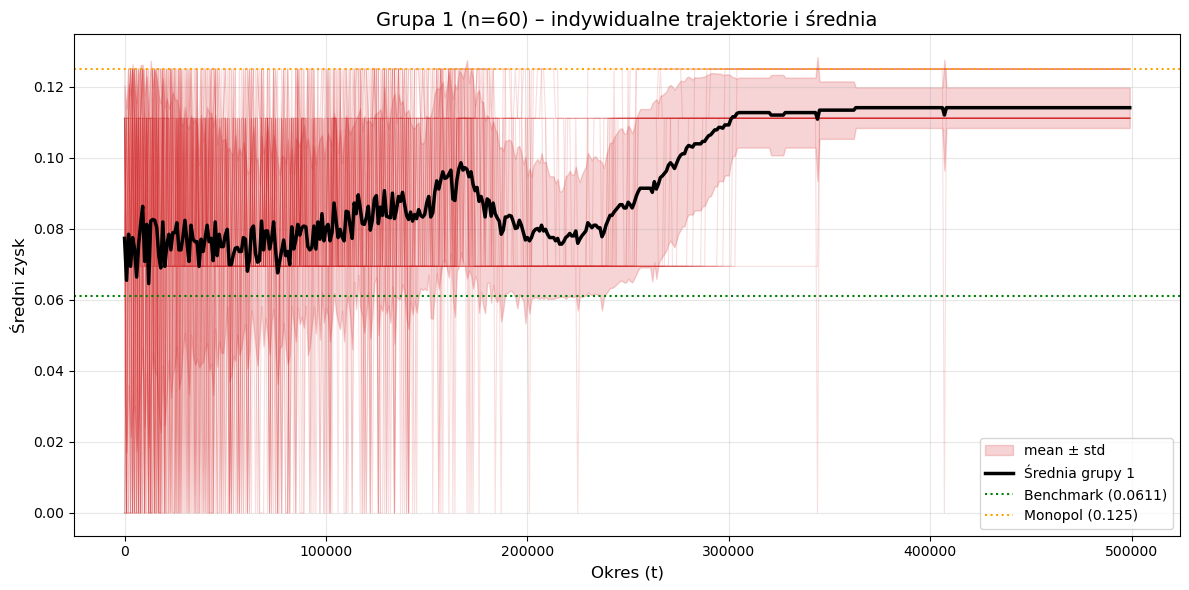

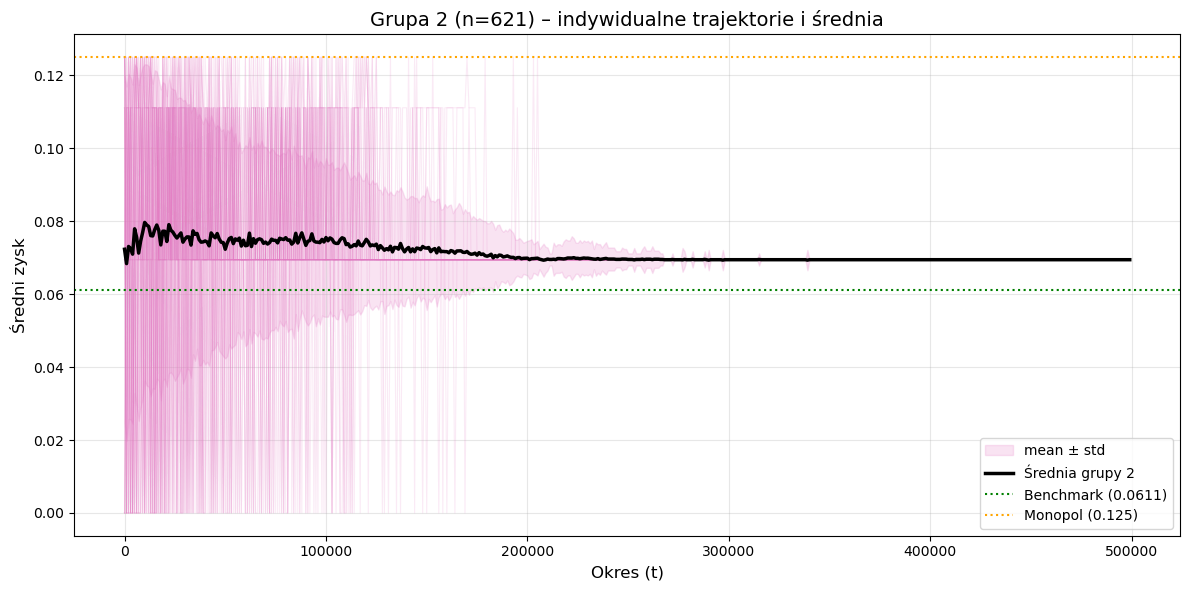

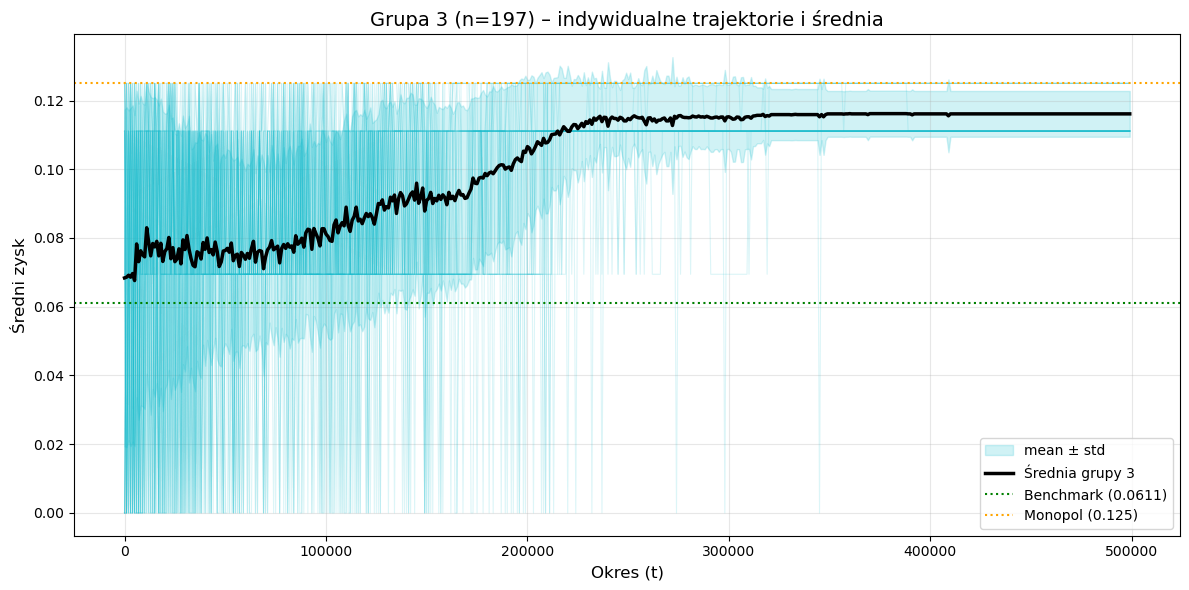

In [23]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tqdm import tqdm

# ===== PARAMETRY =====
step = 1000
T = 500000
t_points = np.arange(0, T, step)
benchmark = 0.0611
monopoly = 0.125
ts_dir = "ts_data"
n_clusters = 4
n_samples_per_cluster = 30   # liczba indywidualnych trajektorii do pokazania

# ===== WCZYTANIE DANYCH (jeśli jeszcze nie wczytane) =====
files = glob.glob(f"{ts_dir}/ts_seed_*.parquet")
print(f"Liczba plików: {len(files)}")

n_seeds = len(files)
n_times = len(t_points)
trajectories = np.zeros((n_seeds, n_times))

for i, f in enumerate(tqdm(files, desc="Wczytywanie trajektorii")):
    df = pd.read_parquet(f)
    df_sampled = df.iloc[::step].copy()
    trajectories[i, :] = (df_sampled['pi1'] + df_sampled['pi2']).values / 2

trajectories = np.nan_to_num(trajectories, nan=0.0)

# ===== KLASTERYZACJA (jeśli jeszcze nie wykonana) =====
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(trajectories)

unique, counts = np.unique(labels, return_counts=True)
print("Liczebności grup:")
for u, c in zip(unique, counts):
    print(f"Grupa {u}: n={c}")

# ===== WYKRESY OSOBNE DLA KAŻDEJ GRUPY =====
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for label in unique:
    mask = labels == label
    group_trajs = trajectories[mask]
    n_group = len(group_trajs)

    # Średnia i odchylenie
    mean_traj = group_trajs.mean(axis=0)
    std_traj = group_trajs.std(axis=0)

    # Przygotowanie figury
    plt.figure(figsize=(12, 6))

    # Losowe wybrane trajektorie
    sample_indices = np.random.choice(n_group, size=min(n_samples_per_cluster, n_group), replace=False)
    for i in sample_indices:
        plt.plot(t_points, group_trajs[i], color=colors[label], alpha=0.15, linewidth=0.8)

    # Pasmo odchylenia standardowego (mean ± std)
    plt.fill_between(t_points, mean_traj - std_traj, mean_traj + std_traj,
                     color=colors[label], alpha=0.2, label='mean ± std')

    # Średnia grupy
    plt.plot(t_points, mean_traj, color='black', linewidth=2.5, label=f'Średnia grupy {label}')

    # Linie odniesienia
    plt.axhline(benchmark, color='green', linestyle=':', linewidth=1.5, label=f'Benchmark ({benchmark})')
    plt.axhline(monopoly, color='orange', linestyle=':', linewidth=1.5, label=f'Monopol ({monopoly})')

    plt.xlabel('Okres (t)', fontsize=12)
    plt.ylabel('Średni zysk', fontsize=12)
    plt.title(f'Grupa {label} (n={n_group}) – indywidualne trajektorie i średnia', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'cluster_{label}.png', dpi=150)
    # plt.close()

print("Wykresy zapisane jako cluster_0.png, cluster_1.png, ...")

Liczba plików: 1000


Wczytywanie trajektorii: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 71.85it/s]


Liczebności grup:
Grupa 0: n=122
Grupa 1: n=60
Grupa 2: n=621
Grupa 3: n=197
Zapisano: cluster_plots/cluster_0_profit.png
Zapisano: cluster_plots/cluster_1_profit.png
Zapisano: cluster_plots/cluster_2_profit.png
Zapisano: cluster_plots/cluster_3_profit.png
Wykonano


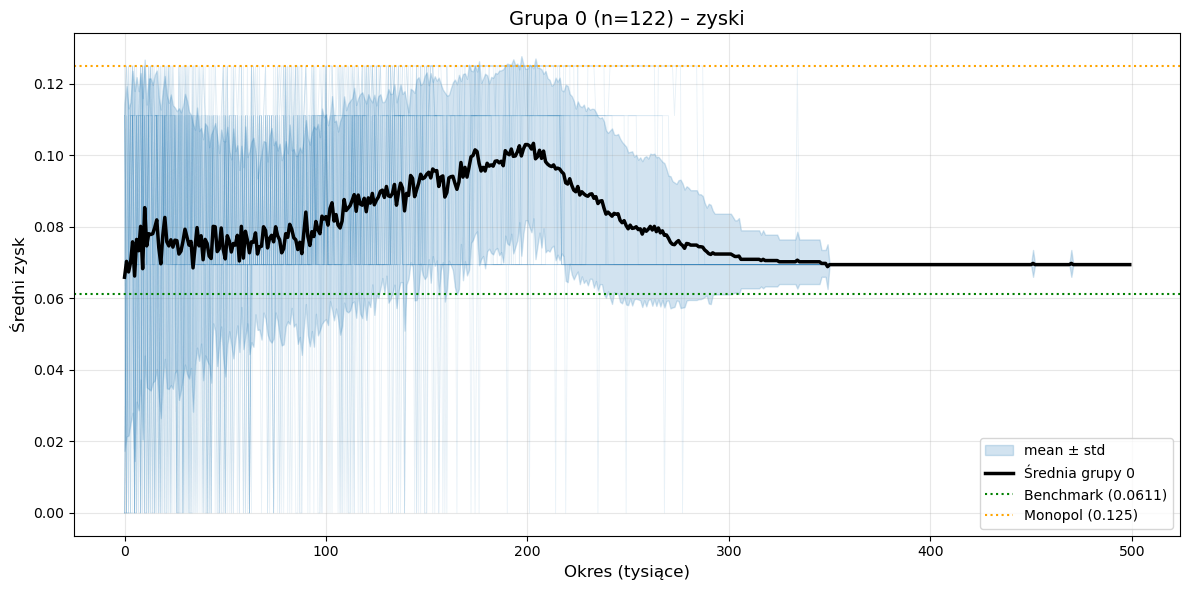

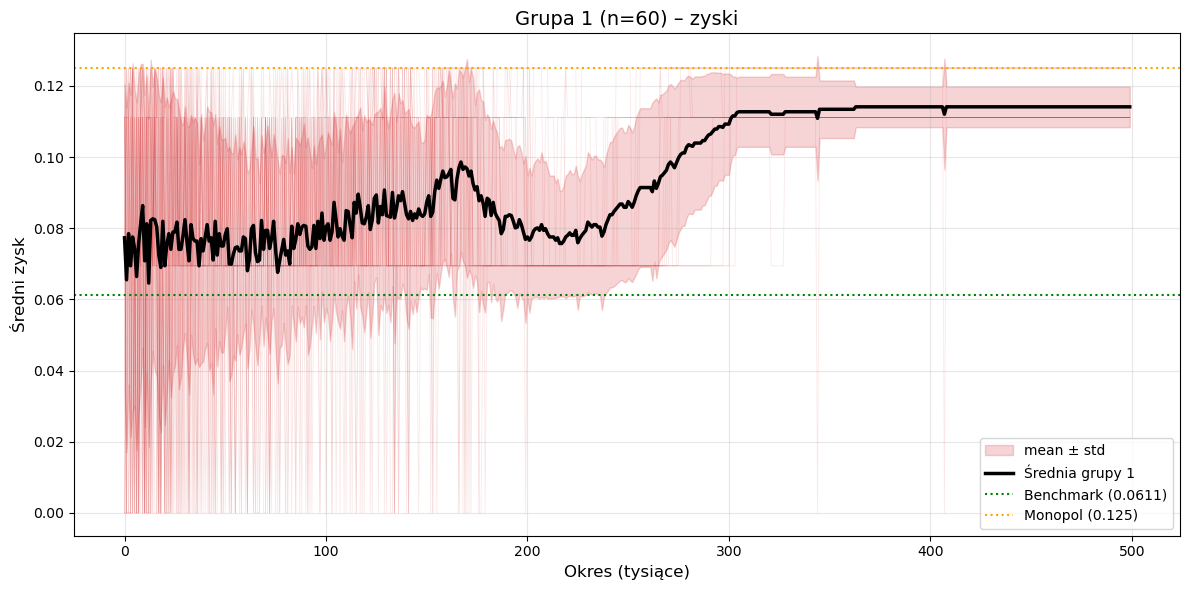

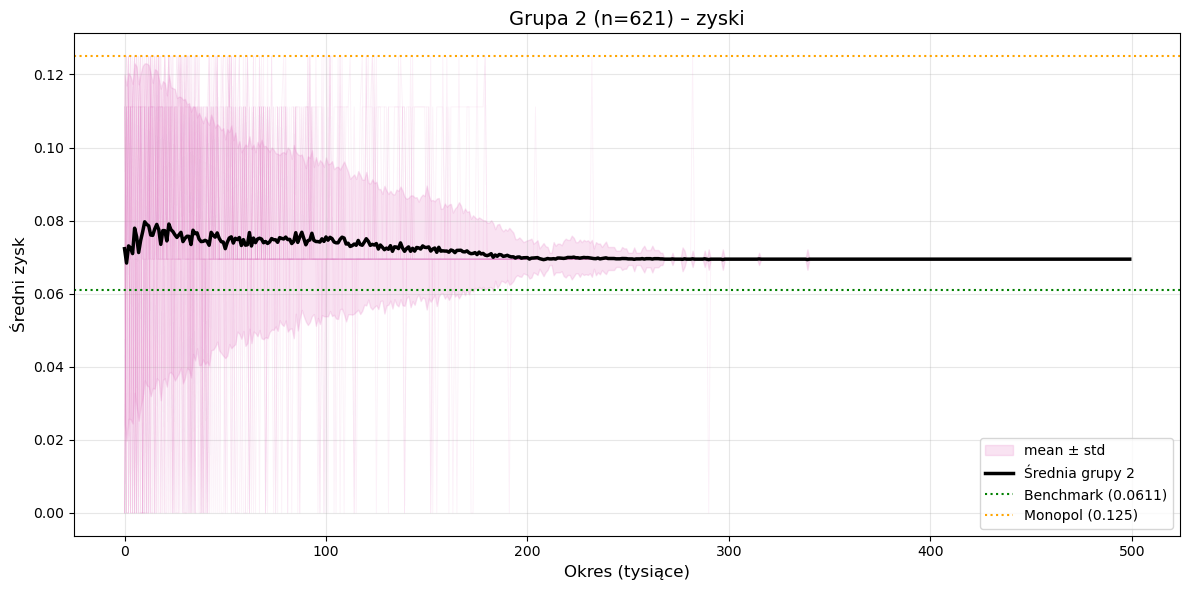

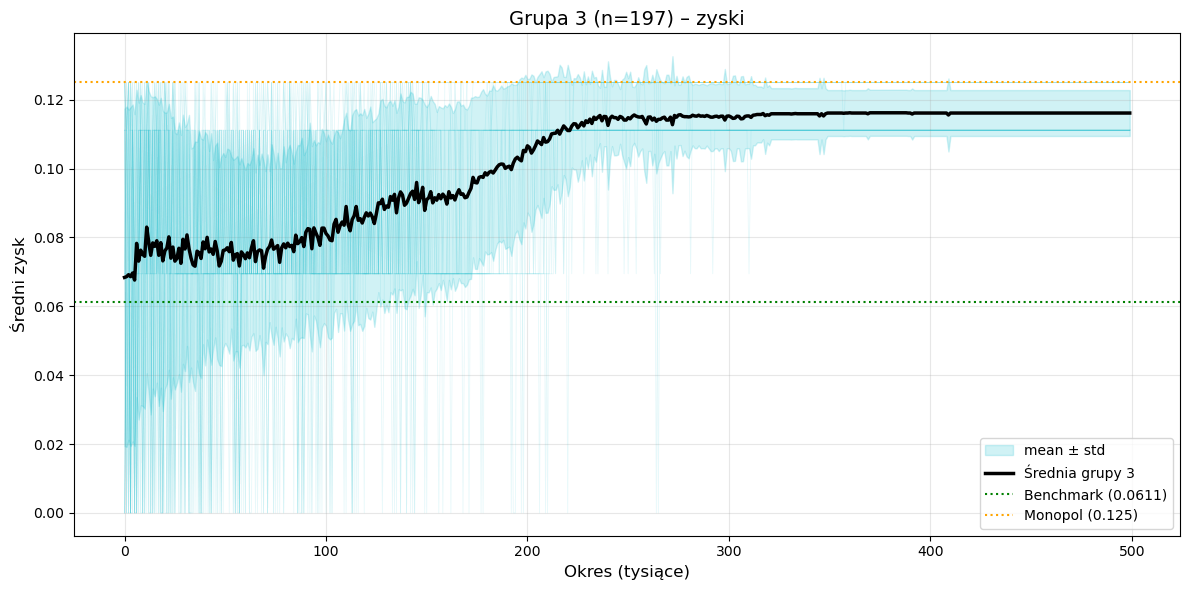

In [24]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tqdm import tqdm
import os

# ===== PARAMETRY =====
step = 1000
T = 500000
t_points = np.arange(0, T, step) / 1000  # oś w tysiącach okresów
benchmark = 0.0611
monopoly = 0.125
ts_dir = "ts_data"  # katalog z plikami .parquet
n_clusters = 4
n_samples_per_cluster = 20   # liczba indywidualnych trajektorii
plot_prices = False          # False = zyski, True = ceny
output_dir = "cluster_plots"  # katalog na wykresy

# Utwórz katalog wyjściowy
os.makedirs(output_dir, exist_ok=True)

# ===== WCZYTANIE DANYCH =====
files = glob.glob(f"{ts_dir}/ts_seed_*.parquet")
print(f"Liczba plików: {len(files)}")

if len(files) == 0:
    raise FileNotFoundError(f"Brak plików .parquet w katalogu {ts_dir}")

# Przyjmijmy, że wszystkie pliki mają tę samą długość (T)
n_seeds = len(files)
n_times = len(t_points)
trajectories = np.zeros((n_seeds, n_times))

for i, f in enumerate(tqdm(files, desc="Wczytywanie trajektorii")):
    df = pd.read_parquet(f)
    # Upewnij się, że mamy odpowiednie kolumny
    if 'pi1' not in df.columns or 'pi2' not in df.columns:
        print(f"Ostrzeżenie: plik {f} nie ma kolumn pi1/pi2, pomijam")
        continue
    df_sampled = df.iloc[::step].copy()
    if plot_prices:
        # Średnia cena rynkowa
        trajectories[i, :] = (df_sampled['p1'] + df_sampled['p2']).values / 2
    else:
        # Średni zysk
        trajectories[i, :] = (df_sampled['pi1'] + df_sampled['pi2']).values / 2

trajectories = np.nan_to_num(trajectories, nan=0.0)

# ===== KLASTERYZACJA =====
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(trajectories)

unique, counts = np.unique(labels, return_counts=True)
print("Liczebności grup:")
for u, c in zip(unique, counts):
    print(f"Grupa {u}: n={c}")

# ===== WYKRESY =====
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for label in unique:
    mask = labels == label
    group_trajs = trajectories[mask]
    n_group = len(group_trajs)

    mean_traj = group_trajs.mean(axis=0)
    std_traj = group_trajs.std(axis=0)

    plt.figure(figsize=(12, 6))

    # Rysowanie poszczególnych trajektorii
    sample_indices = np.random.choice(n_group, size=min(n_samples_per_cluster, n_group), replace=False)
    for i in sample_indices:
        plt.plot(t_points, group_trajs[i], color=colors[label], alpha=0.1, linewidth=0.6)

    # Pasmo odchylenia standardowego
    plt.fill_between(t_points, mean_traj - std_traj, mean_traj + std_traj,
                     color=colors[label], alpha=0.2, label='mean ± std')

    # Średnia grupy
    plt.plot(t_points, mean_traj, color='black', linewidth=2.5, label=f'Średnia grupy {label}')

    # Linie odniesienia
    if plot_prices:
        y_bench = 0.5  # cena monopolowa? Ale benchmark dla cen to nie 0.0611
        y_mono = 0.5
        plt.axhline(0.5, color='orange', linestyle=':', linewidth=1.5, label='Cena monopolowa (0.5)')
        plt.axhline(0.3, color='green', linestyle=':', linewidth=1.5, label='Przykładowa cena konkurencyjna?')
    else:
        plt.axhline(benchmark, color='green', linestyle=':', linewidth=1.5, label=f'Benchmark ({benchmark})')
        plt.axhline(monopoly, color='orange', linestyle=':', linewidth=1.5, label=f'Monopol ({monopoly})')

    plt.xlabel('Okres (tysiące)', fontsize=12)
    ylabel = 'Średnia cena rynkowa' if plot_prices else 'Średni zysk'
    plt.ylabel(ylabel, fontsize=12)
    plt.title(f'Grupa {label} (n={n_group}) – {"ceny" if plot_prices else "zyski"}', fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    output_filename = os.path.join(output_dir, f'cluster_{label}_{"price" if plot_prices else "profit"}.png')
    plt.savefig(output_filename, dpi=150)
    # plt.close()
    print(f"Zapisano: {output_filename}")

print("Wykonano")

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ===== WCZYTANIE DANYCH =====
results = pd.read_csv("results.csv")  # plik z podsumowaniami
print(f"Załadowano {len(results)} wierszy z results.csv")

# ===== WCZYTANIE ETYKIET KLASTRÓW =====
# Zakładam, że wcześniej zapisałeś etykiety do pliku cluster_labels.csv
# Plik ten zawiera kolumny: seed, cluster
try:
    labels_df = pd.read_csv("cluster_labels.csv")
    print(f"Wczytano {len(labels_df)} etykiet z cluster_labels.csv")
except FileNotFoundError:
    print("Brak pliku cluster_labels.csv. Najpierw wykonaj klasteryzację trajektorii.")
    # Można też spróbować odtworzyć, ale to wymaga danych czasowych – lepiej zakończyć.
    raise SystemExit("Zatrzymuję skrypt – najpierw uruchom klasteryzację.")

# Scalanie po kolumnie 'seed' (upewniamy się, że obie ramki mają tę kolumnę)
if 'seed' not in results.columns:
    print("UWAGA: results.csv nie ma kolumny 'seed' – nie można połączyć.")
    # Jeśli nie ma seed, może być inny identyfikator? W symulacji seed jest zapisywany.
    # W kodzie self_play_one zwraca słownik z kluczem 'seed', więc powinien być.
    raise SystemExit("Brak kolumny 'seed' w results.csv")

# Sprawdź, czy wszystkie seed z results są w labels_df
merged = pd.merge(results, labels_df, on='seed', how='inner')
if len(merged) != len(results):
    print(f"Uwaga: scalono tylko {len(merged)} z {len(results)} wierszy – niektóre seedy nie mają etykiet.")
results = merged  # teraz results ma kolumnę 'cluster'

# ===== KROK 2.1: Podstawowe statystyki dla każdej grupy =====
stats = results.groupby('cluster').agg({
    'avg_profit': ['mean', 'std'],
    'avg_price': ['mean', 'std'],
    'std_market': ['mean', 'std'],
    'cycle_amp': ['mean', 'std'],
    'jump_count_large': ['mean', 'std']
}).round(4)

# ===== KROK 2.2: Częstość reżimów =====
regime_summary = results.groupby('cluster')['regime'].value_counts(normalize=True).unstack().fillna(0)

# Udział pary monopolowej
monopoly_share = results.groupby('cluster')['share_state_05_05'].mean().round(4)

# ===== KROK 2.3: Dominująca cena dla grup o niskim std_market =====
def parse_mode_pair(mode_str):
    try:
        p1, p2 = map(float, mode_str.strip('()').split(','))
        return (p1 + p2) / 2
    except:
        return np.nan

results['mode_avg_price'] = results['mode_pair'].apply(parse_mode_pair)

# # Dla każdej grupy, jeśli średnie std_market < 0.02, oblicz średnią z mode_avg_price
# dominant_price = results.groupby('cluster').apply(
#     lambda g: g['mode_avg_price'].mean() if g['std_market'].mean() < 0.02 else np.nan
# ).round(4)

# Dla grup ze std_market < 0.02 – dominująca cena to średnia cena rynkowa (bo niska zmienność)
dominant_price = results.groupby('cluster').apply(
    lambda g: g['avg_price'].mean() if g['std_market'].mean() < 0.02 else np.nan
).round(4)

# ===== KROK 2.4: Zestawienie wyników =====
summary = pd.DataFrame({
    'Liczebność': results.groupby('cluster').size(),
    'Średni zysk (końcowy)': stats[('avg_profit', 'mean')],
    'Std zysku': stats[('avg_profit', 'std')],
    'Średnia cena': stats[('avg_price', 'mean')],
    'Std ceny': stats[('avg_price', 'std')],
    'Zmienność ceny (std_market)': stats[('std_market', 'mean')],
    'Amplituda cyklu': stats[('cycle_amp', 'mean')],
    'Liczba skoków > tick': stats[('jump_count_large', 'mean')],
    'Udział pary (0.5,0.5)': monopoly_share,
    'Dominująca cena (stałe grupy)': dominant_price
}).round(4)

# Dodajemy informację o reżimach (procentowo)
for regime in regime_summary.columns:
    summary[f'Reżim: {regime}'] = regime_summary[regime].round(4)

print("\n=== PODSUMOWANIE DLA GRUP (stany stacjonarne) ===\n")
print(summary.to_string())

# ===== INTERPRETACJA =====
print("\n=== INTERPRETACJA ===\n")
for cluster in sorted(results['cluster'].unique()):
    row = summary.loc[cluster]
    print(f"Grupa {cluster} (n={int(row['Liczebność'])})")
    print(f"  - Średni zysk: {row['Średni zysk (końcowy)']:.4f} "
          f"(benchmark: 0.0611, monopol: 0.125)")
    print(f"  - Średnia cena: {row['Średnia cena']:.4f}")
    if row['Zmienność ceny (std_market)'] < 0.02:
        print(f"  - **Stała cena**: dominująca cena ok. {row['Dominująca cena (stałe grupy)']:.4f}")
    else:
        print(f"  - **Cykl**: amplituda {row['Amplituda cyklu']:.4f}, "
              f"średnio {row['Liczba skoków > tick']:.1f} skoków w okresie")
    # Wyświetl reżimy (tylko te z wartością >0)
    regimes = {k.split('Reżim: ')[1]: v for k, v in row.filter(like='Reżim:').items() if v > 0}
    print(f"  - Reżimy: {regimes}")
    print(f"  - Udział ceny monopolowej: {row['Udział pary (0.5,0.5)']:.2%}")
    print()

Załadowano 1000 wierszy z results.csv
Wczytano 1000 etykiet z cluster_labels.csv

=== PODSUMOWANIE DLA GRUP (stany stacjonarne) ===

         Liczebność  Średni zysk (końcowy)  Std zysku  Średnia cena  Std ceny  Zmienność ceny (std_market)  Amplituda cyklu  Liczba skoków > tick  Udział pary (0.5,0.5)  Dominująca cena (stałe grupy)  Reżim: cycling/asymmetric  Reżim: focal_equal_price  Reżim: monopoly_regime
cluster                                                                                                                                                                                                                                                                             
0               122                 0.0694     0.0000        0.1674    0.0077                       0.0003           0.0273                0.1148                 0.0000                         0.1674                     0.0082                    0.9918                  0.0000
1                60                 

/tmp/ipykernel_632051/1379642259.py:65: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dominant_price = results.groupby('cluster').apply(
